In [ ]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Conv2DTranspose,BatchNormalization,LeakyReLU,Reshape,Dropout,Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
(train_images, train_labels), (_, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
Batch_size = 64

In [ ]:
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5
train_dataset = tensorflow.data.Dataset.from_tensor_slices(train_images).shuffle(60000).batch(Batch_size)

In [ ]:
def Create_generator_model():
  model = Sequential()

  model.add(Dense(7*7*256,use_bias=False,input_shape=(100,)))
  model.add(BatchNormalization())
  model.add(LeakyReLU())

  model.add(Reshape((7,7,256)))
  model.add(Conv2DTranspose(128,(5,5),strides=(1,1),padding="same"))
  model.add(BatchNormalization())
  model.add(LeakyReLU())

  model.add(Conv2DTranspose(64,(5,5),strides=(2,2),padding="same"))
  model.add(BatchNormalization())
  model.add(LeakyReLU())

  model.add(Conv2DTranspose(1,(5,5),strides=(2,2),padding="same",activation="tanh"))
  return model

In [ ]:
def Create_discriminator_model():
  model = Sequential()
  model.add(Conv2D(64,(5,5),strides=(2,2),padding="same",input_shape=[28,28,1]))
  model.add(LeakyReLU())
  model.add((Dropout(0.3)))

  model.add(Conv2D(128,kernel_size=(5,5),strides=(2,2),padding="same"))
  model.add(LeakyReLU())
  model.add(Dropout(0.3))

  model.add(Flatten())
  model.add(Dense(1))

  return model


In [ ]:
noise_dim = 100
Discriminator = Create_discriminator_model()
Generator = Create_generator_model()
cross_entropy_loss = BinaryCrossentropy(from_logits=True)
Generator_optimizer = Adam(learning_rate=0.0001)
Discriminator_optimizer = Adam(learning_rate=0.0001)

In [ ]:
def Discriminator_error(real_output,fake_output):
  real_loss = cross_entropy_loss(tensorflow.ones_like(real_output),real_output)
  fake_loss = cross_entropy_loss(tensorflow.zeros_like(fake_output),fake_output)
  total_loss = real_loss + fake_loss
  return total_loss
def Generator_error(fake_output):
  return cross_entropy_loss(tensorflow.ones_like(fake_output),fake_output)


In [ ]:
checkpoint_dir = './training_checkpoint'
checkpoint_prefix = os.path.join(checkpoint_dir,'ckpt')
checkpoint = tensorflow.train.Checkpoint(
    generator_optimizer = Generator_optimizer,
    discriminator_optimizer = Discriminator_optimizer,
    generator = Generator,
    discriminator = Discriminator
)


In [ ]:
@tensorflow.function
def train_step(images):
  noise = tensorflow.random.normal([Batch_size,noise_dim])

  with tensorflow.GradientTape() as gen_tape, tensorflow.GradientTape() as dis_tape:
    Generated_img = Generator(noise,training=True)

    real_output = Discriminator(images,training=True)
    fake_output = Discriminator(Generated_img,training = True)

    gen_loss = Generator_error(fake_output)
    dis_loss = Discriminator_error(real_output,fake_output)

  generator_grad = gen_tape.gradient(gen_loss,Generator.trainable_variables)
  discriminator_grad = dis_tape.gradient(dis_loss,Discriminator.trainable_variables)

  Generator_optimizer.apply_gradients(zip(generator_grad,Generator.trainable_variables))
  Discriminator_optimizer.apply_gradients(zip(discriminator_grad,Discriminator.trainable_variables))
  return gen_loss,dis_loss


In [ ]:
fixed_noise = tensorflow.random.normal([16,noise_dim])
def train(dataset,epochs):
  for epoch in range(epochs):
    per_epoch_dis_loss = 0.0
    per_epoch_gen_loss = 0.0
    print(f"Printing the results of epoch - {epoch+1}")
    for image in dataset:
      gen_loss,dis_loss = train_step(image)
      per_epoch_dis_loss = per_epoch_dis_loss + dis_loss
      per_epoch_gen_loss = per_epoch_gen_loss + gen_loss
    tensorflow.print(f"Discriminator loss : {per_epoch_dis_loss/len(dataset):4f},Generator loss : {per_epoch_gen_loss/len(dataset):4f}")
    generate_save_imgs(Generator,epoch,fixed_noise)
  if (epoch+1) % 15 == 0:
    checkpoint.save(file_prefix=checkpoint_prefix)

In [ ]:
def generate_save_imgs(model,epoch,test_input):
  predictions = model(test_input,train=False)
  fig = plt.figure(figsize=(4,4))

  for i in range(predictions.shape[0]):
    plt.subplot(4,4,i+1)
    plt.imshow(predictions[i,:,:,0],cmap="gray")
    plt.axis("off")
  plt.savefig("img_at_epoch_{:04d}.png".format(epoch))
  plt.show()


Printing the results of epoch - 1
Discriminator loss : 1.029403,Generator loss : 1.019354


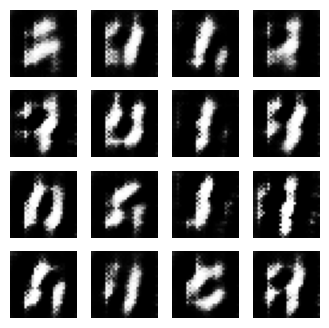

Printing the results of epoch - 2
Discriminator loss : 1.247944,Generator loss : 0.909432


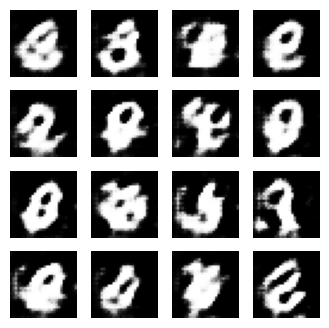

Printing the results of epoch - 3
Discriminator loss : 1.241781,Generator loss : 0.900786


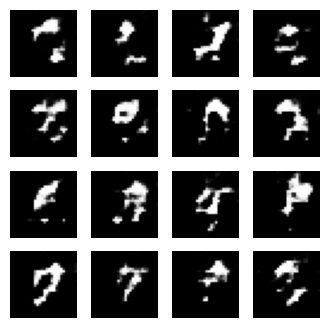

Printing the results of epoch - 4
Discriminator loss : 1.162235,Generator loss : 1.004298


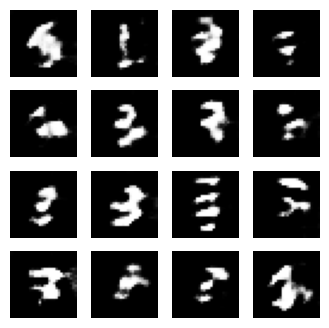

Printing the results of epoch - 5
Discriminator loss : 1.145330,Generator loss : 1.076065


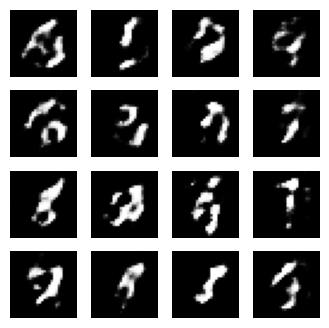

Printing the results of epoch - 6
Discriminator loss : 1.105099,Generator loss : 1.089102


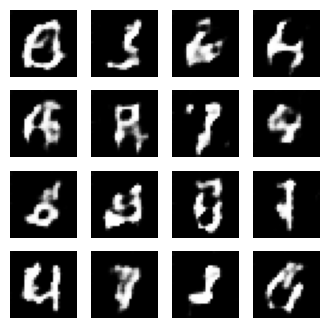

Printing the results of epoch - 7
Discriminator loss : 1.053540,Generator loss : 1.203484


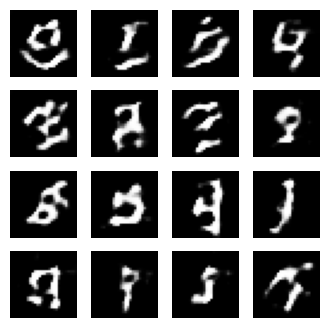

Printing the results of epoch - 8
Discriminator loss : 1.146029,Generator loss : 1.077964


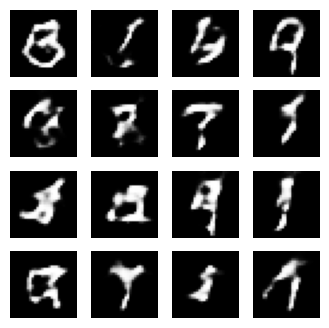

Printing the results of epoch - 9
Discriminator loss : 1.206362,Generator loss : 1.002742


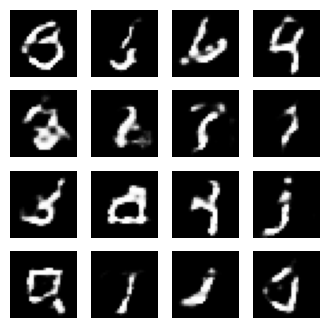

Printing the results of epoch - 10
Discriminator loss : 1.226195,Generator loss : 0.966507


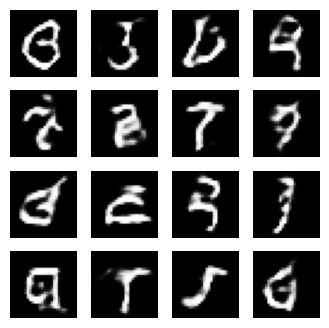

Printing the results of epoch - 11
Discriminator loss : 1.216295,Generator loss : 0.986873


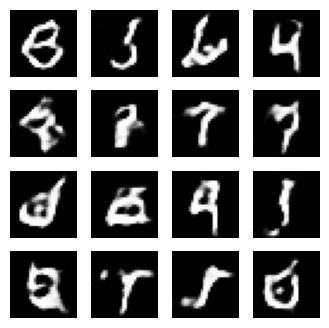

Printing the results of epoch - 12
Discriminator loss : 1.246398,Generator loss : 0.910430


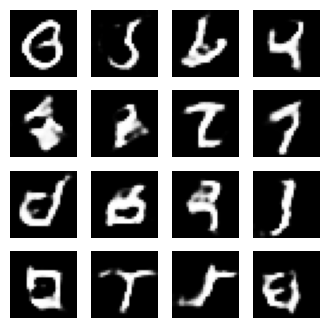

Printing the results of epoch - 13
Discriminator loss : 1.246833,Generator loss : 0.921142


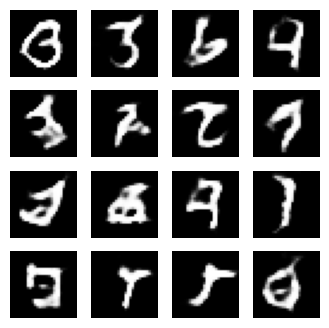

Printing the results of epoch - 14
Discriminator loss : 1.246044,Generator loss : 0.909472


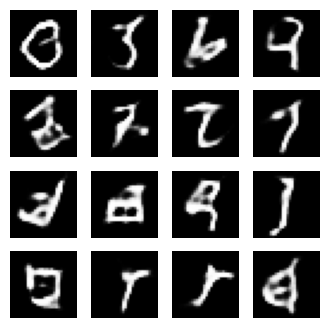

Printing the results of epoch - 15
Discriminator loss : 1.251160,Generator loss : 0.895277


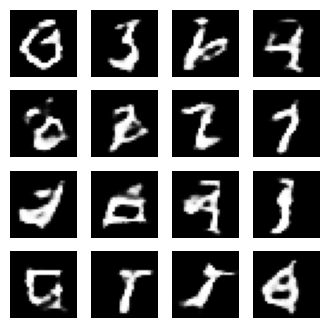

Printing the results of epoch - 16
Discriminator loss : 1.231793,Generator loss : 0.929994


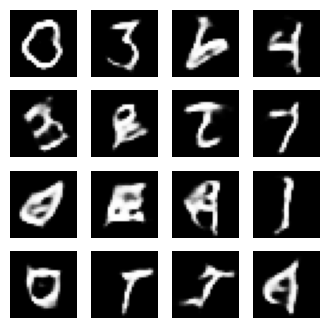

Printing the results of epoch - 17
Discriminator loss : 1.250978,Generator loss : 0.900922


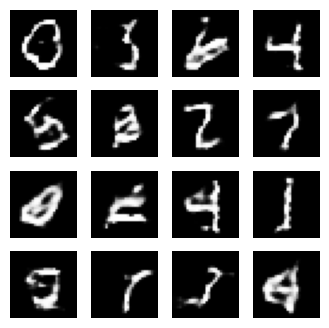

Printing the results of epoch - 18
Discriminator loss : 1.249609,Generator loss : 0.908985


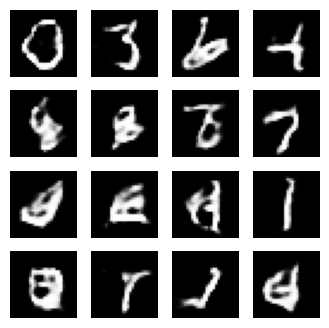

Printing the results of epoch - 19
Discriminator loss : 1.258612,Generator loss : 0.882611


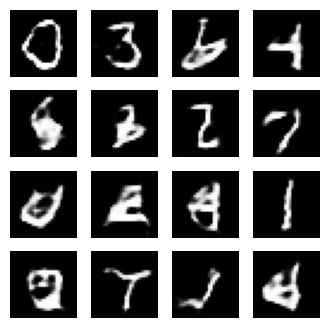

Printing the results of epoch - 20
Discriminator loss : 1.258300,Generator loss : 0.882504


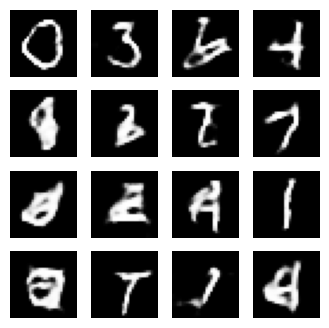

Printing the results of epoch - 21
Discriminator loss : 1.252822,Generator loss : 0.896097


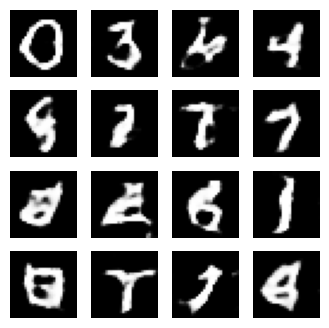

Printing the results of epoch - 22
Discriminator loss : 1.251106,Generator loss : 0.900220


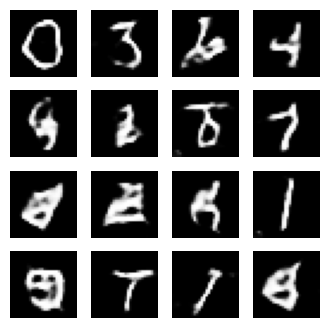

Printing the results of epoch - 23
Discriminator loss : 1.255365,Generator loss : 0.905284


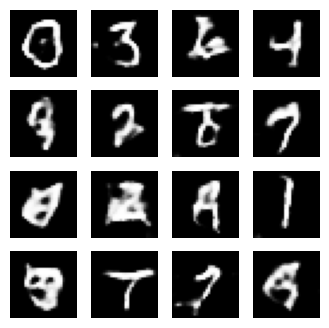

Printing the results of epoch - 24
Discriminator loss : 1.258492,Generator loss : 0.894095


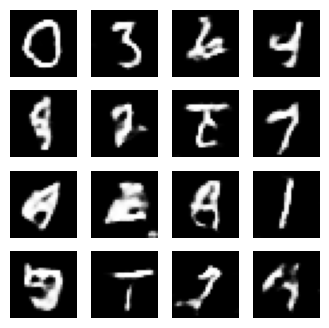

Printing the results of epoch - 25
Discriminator loss : 1.258749,Generator loss : 0.889530


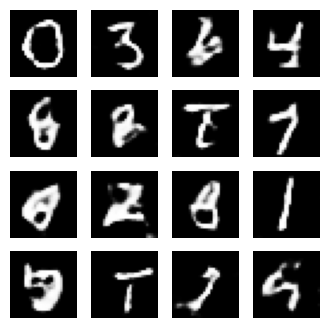

Printing the results of epoch - 26
Discriminator loss : 1.255557,Generator loss : 0.903859


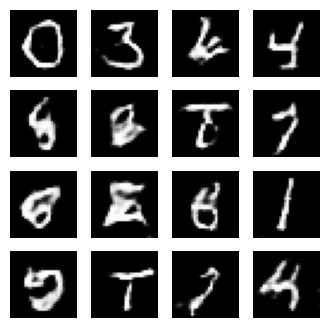

Printing the results of epoch - 27
Discriminator loss : 1.264980,Generator loss : 0.876690


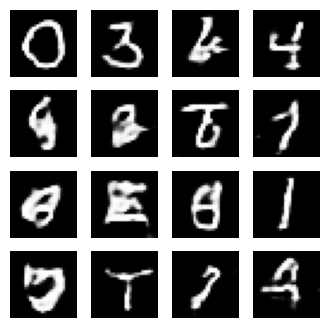

Printing the results of epoch - 28
Discriminator loss : 1.261452,Generator loss : 0.893859


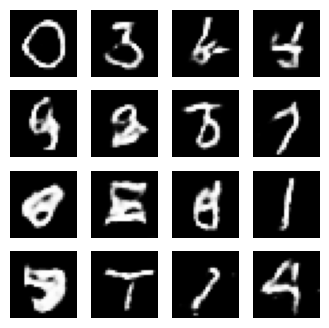

Printing the results of epoch - 29
Discriminator loss : 1.261399,Generator loss : 0.897648


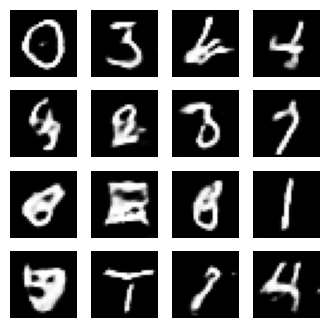

Printing the results of epoch - 30
Discriminator loss : 1.265420,Generator loss : 0.876211


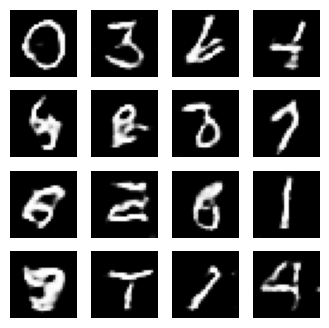

Printing the results of epoch - 31
Discriminator loss : 1.264487,Generator loss : 0.900683


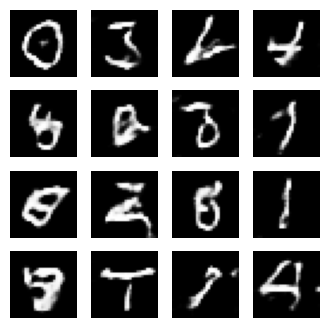

Printing the results of epoch - 32
Discriminator loss : 1.256000,Generator loss : 0.898149


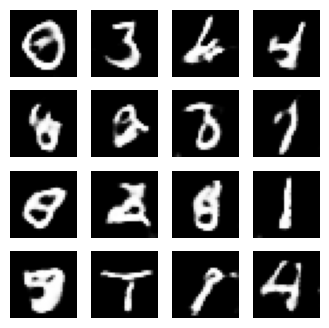

Printing the results of epoch - 33
Discriminator loss : 1.259459,Generator loss : 0.897425


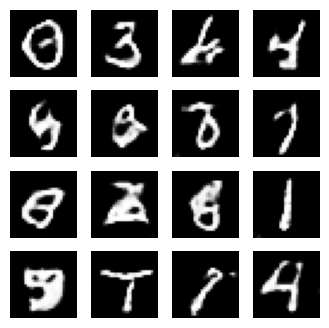

Printing the results of epoch - 34
Discriminator loss : 1.258523,Generator loss : 0.899711


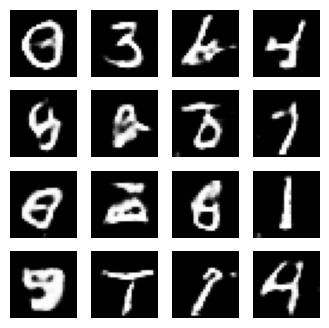

Printing the results of epoch - 35
Discriminator loss : 1.264574,Generator loss : 0.883479


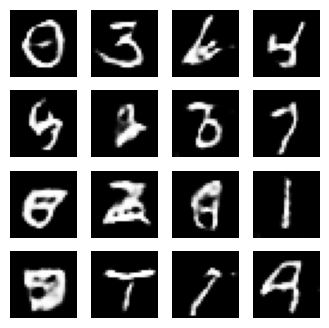

Printing the results of epoch - 36
Discriminator loss : 1.262960,Generator loss : 0.894611


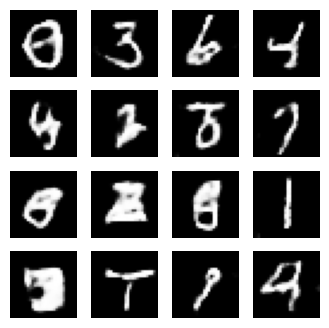

Printing the results of epoch - 37
Discriminator loss : 1.269529,Generator loss : 0.874270


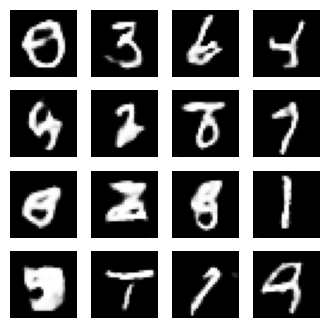

Printing the results of epoch - 38
Discriminator loss : 1.261260,Generator loss : 0.900265


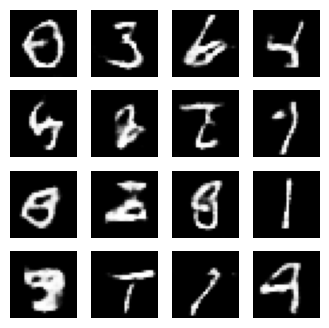

Printing the results of epoch - 39
Discriminator loss : 1.260702,Generator loss : 0.889904


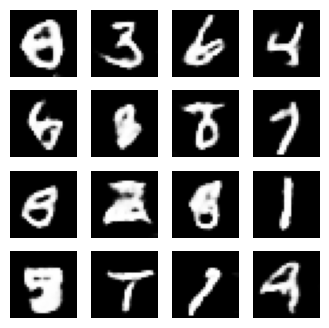

Printing the results of epoch - 40
Discriminator loss : 1.265884,Generator loss : 0.878300


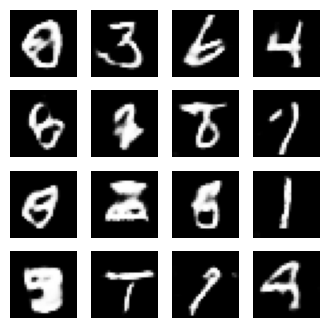

Printing the results of epoch - 41
Discriminator loss : 1.265969,Generator loss : 0.892757


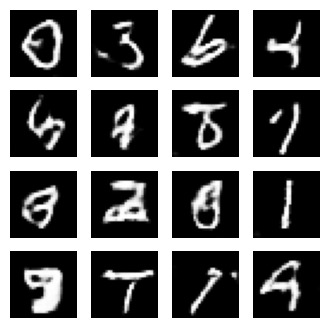

Printing the results of epoch - 42
Discriminator loss : 1.265473,Generator loss : 0.883442


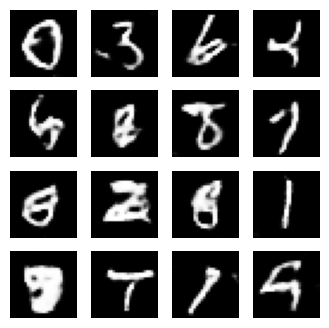

Printing the results of epoch - 43
Discriminator loss : 1.266112,Generator loss : 0.883646


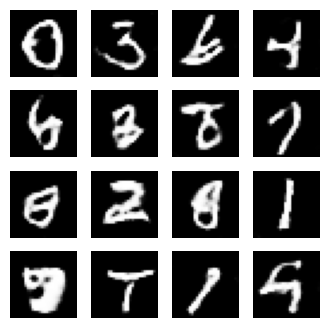

Printing the results of epoch - 44
Discriminator loss : 1.270299,Generator loss : 0.880418


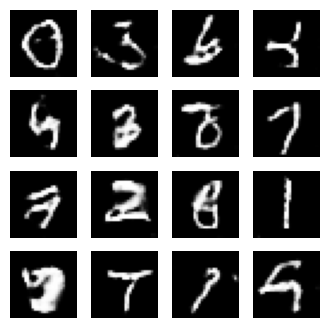

Printing the results of epoch - 45
Discriminator loss : 1.269459,Generator loss : 0.882578


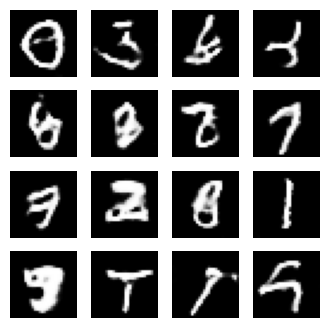

Printing the results of epoch - 46
Discriminator loss : 1.268387,Generator loss : 0.882124


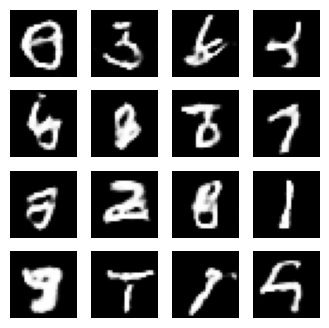

Printing the results of epoch - 47
Discriminator loss : 1.271976,Generator loss : 0.881087


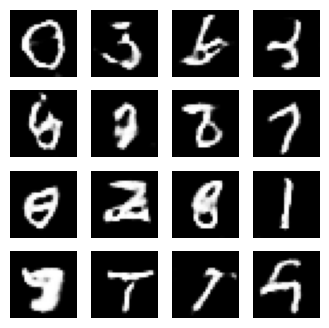

Printing the results of epoch - 48
Discriminator loss : 1.276151,Generator loss : 0.875111


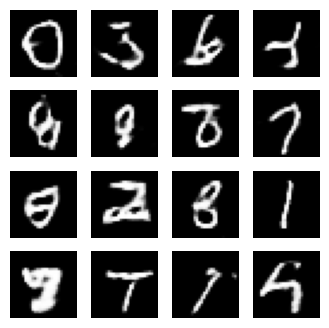

Printing the results of epoch - 49
Discriminator loss : 1.269083,Generator loss : 0.880473


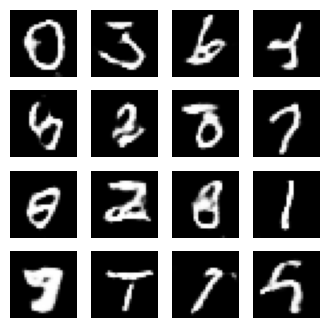

Printing the results of epoch - 50
Discriminator loss : 1.273281,Generator loss : 0.874030


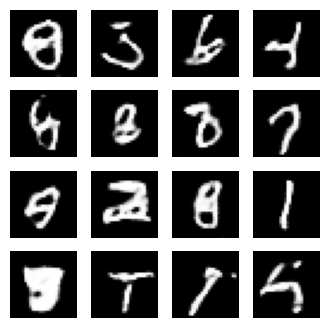

In [ ]:
train(train_dataset,50)